In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [227]:
df = pd.read_csv("../data/processed/US_2020.csv", low_memory=False)

print("Shape:", df.shape)
df.head()


Shape: (225901, 17)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,38585,Charming Victorian home - twin beds + breakfast,165529,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,80905,French Chic Loft,427027,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,320564,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.57864,-82.59578,Entire home/apt,90,1,267,22/09/20,2.39,5,0,Asheville
4,160594,Historic Grove Park,769252,Elizabeth,NaN,28801,35.61442,-82.54127,Private room,125,30,58,19/10/15,0.52,1,0,Asheville


In [228]:
df.info()

print("\nMissing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nPrice summary:")
display(df["price"].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225901 entries, 0 to 225900
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              225901 non-null  int64  
 1   name                            225872 non-null  object 
 2   host_id                         225901 non-null  int64  
 3   host_name                       225868 non-null  object 
 4   neighbourhood_group             110114 non-null  object 
 5   neighbourhood                   225901 non-null  object 
 6   latitude                        225901 non-null  float64
 7   longitude                       225901 non-null  float64
 8   room_type                       225901 non-null  object 
 9   price                           225901 non-null  int64  
 10  minimum_nights                  225901 non-null  int64  
 11  number_of_reviews               225901 non-null  int64  
 12  last_review     

neighbourhood_group               115787
reviews_per_month                  48540
last_review                        48540
host_name                             33
name                                  29
id                                     0
minimum_nights                         0
availability_365                       0
calculated_host_listings_count         0
number_of_reviews                      0
dtype: int64


Price summary:


count    225901.000000
mean        219.622702
std         569.157414
min           1.000000
25%          75.000000
50%         122.000000
75%         201.000000
max       24999.000000
Name: price, dtype: float64

In [229]:
# log transform price (price is already > 0 after SQL cleaning)
df["log_price"] = np.log(df["price"])

# host listing count from data
df["host_listing_count"] = df.groupby("host_id")["id"].transform("count")

# host tiers
def host_tier(n):
    if n == 1:
        return "Single Listing"
    elif n <= 5:
        return "Small Host (2–5)"
    elif n <= 20:
        return "Professional (6–20)"
    else:
        return "Enterprise (20+)"

df["host_tier"] = df["host_listing_count"].apply(host_tier)

df[["price", "log_price", "host_listing_count", "host_tier"]].head()

,price,log_price,host_listing_count,host_tier
0,60,4.094345,1,Single Listing
1,470,6.152733,11,Professional (6–20)
2,75,4.317488,2,Small Host (2–5)
3,90,4.499810,5,Small Host (2–5)
4,125,4.828314,1,Single Listing


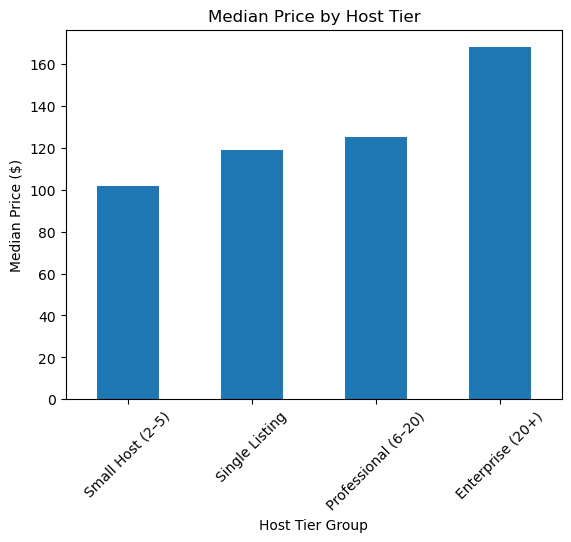

room_type,Entire home/apt,Hotel room,Private room,Shared room
host_tier,,,,
Enterprise (20+),85.78,2.04,9.34,2.84
Professional (6–20),63.84,2.94,29.25,3.97
Single Listing,69.75,0.06,29.17,1.01
Small Host (2–5),57.55,0.54,40.41,1.51


In [230]:
# Host Tier Analysis
df["host_tier"].value_counts(normalize=True).mul(100).round(2)

median_prices = df.groupby("host_tier")["price"].median().sort_values()

plt.figure()
median_prices.plot(kind="bar")
plt.title("Median Price by Host Tier")
plt.xlabel("Host Tier Group")
plt.ylabel("Median Price ($)")
plt.xticks(rotation=45)
plt.show()

room_mix = df.groupby(["host_tier", "room_type"])["id"].count().unstack()
room_mix_pct = room_mix.div(room_mix.sum(axis=1), axis=0) * 100
room_mix_pct.round(2)

In [231]:
# Number of distinct cities within each host tier group
df.groupby("host_tier")["city"].nunique()

host_tier
Enterprise (20+)       27
Professional (6–20)    28
Single Listing         28
Small Host (2–5)       28
Name: city, dtype: int64

In [232]:
# Number of listings for Enterprise group for the top 10 cities
df[df["host_tier"] == "Enterprise (20+)"]["city"].value_counts().head(10)

city
Hawaii            9203
Los Angeles       3219
New York City     2481
Clark County      2008
Broward County    1903
San Diego         1879
Austin            1543
San Francisco     1390
Nashville         1229
Seattle           1148
Name: count, dtype: int64

In [233]:
# Median price for each room type and host tier group
df.groupby(["host_tier", "room_type"])["price"].median().unstack()

room_type,Entire home/apt,Hotel room,Private room,Shared room
host_tier,,,,
Enterprise (20+),179.0,151.0,59.0,29.0
Professional (6–20),159.0,197.5,60.0,30.0
Single Listing,149.0,175.0,70.0,60.0
Small Host (2–5),150.0,170.0,65.0,39.5


In [234]:
# Median number of reviews for each host tier group
df.groupby("host_tier")["number_of_reviews"].median()

host_tier
Enterprise (20+)        2.0
Professional (6–20)     9.0
Single Listing          8.0
Small Host (2–5)       15.0
Name: number_of_reviews, dtype: float64

In [235]:
# Median reviews per month for each host tier group
df.groupby("host_tier")["reviews_per_month"].median()

host_tier
Enterprise (20+)       0.41
Professional (6–20)    1.00
Single Listing         0.75
Small Host (2–5)       1.02
Name: reviews_per_month, dtype: float64

In [236]:
# Median availability in days for each host tier group and room type
df.groupby(["host_tier", "room_type"])["availability_365"].median().unstack()

room_type,Entire home/apt,Hotel room,Private room,Shared room
host_tier,,,,
Enterprise (20+),267.0,66.5,161.0,354.5
Professional (6–20),242.0,249.5,194.0,250.0
Single Listing,80.0,127.0,37.0,9.0
Small Host (2–5),173.0,186.0,129.0,125.0


## Pricing Model

Objective: Estimate the structural drivers of Airbnb listing prices using a log-linear regression model.

I have modelled log (price) as a function of:
- Room type  
- City (location fixed effects)
- Host tier  
- Minimum nights  
- Availability  
- Review-based demand signals  

The log transformation reduces skew and allows coefficients to be interpreted approximately as percentage changes.


In [237]:
model_df = df.copy()

# Keep only columns we want to model with
model_df = model_df.dropna(subset=[
    "log_price",
    "room_type",
    "city",
    "host_tier",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month"
])

# One-hot encode categoricals
model_df = pd.get_dummies(
    model_df,
    columns=["room_type", "host_tier", "city"],
    drop_first=True
)

# Features
X = model_df[[
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_listing_count",
    "latitude",
    "longitude"
] + [c for c in model_df.columns if c.startswith("room_type_") or c.startswith("host_tier_") or c.startswith("city_")]]

# Target
y = model_df["log_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (177361, 40)
y shape: (177361,)


In [238]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R²:", round(r2_score(y_test, y_pred), 4))
print("MAE (log):", round(mean_absolute_error(y_test, y_pred), 4))


R²: 0.3507
MAE (log): 0.4678


In [239]:
actual_prices = np.exp(y_test)
pred_prices = np.exp(y_pred)

mae_dollars = mean_absolute_error(actual_prices, pred_prices)
mape = (np.abs(actual_prices - pred_prices) / actual_prices).mean()

print("MAE ($):", round(mae_dollars, 2))
print("MAPE:", round(mape * 100, 2), "%")


MAE ($): 100.16
MAPE: 48.94 %


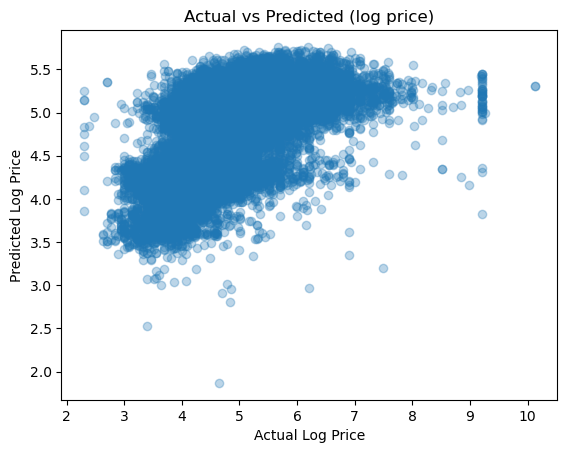

In [240]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted (log price)")
plt.show()


In [241]:
# Interpret coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": lr.coef_,
})

coef_df["pct_effect_approx"] = (np.exp(coef_df["coef"]) - 1) * 100
coef_df.sort_values("pct_effect_approx", ascending=False).head(15)


,feature,coef,pct_effect_approx
16,city_Cambridge,2.824859,1585.857090
30,city_Rhode Island,2.708769,1401.079318
14,city_Boston,2.632325,1290.605913
26,city_New York City,1.845430,533.081930
22,city_Jersey City,1.701857,448.411922
39,city_Washington D.C.,1.079459,194.308648
19,city_Columbus,0.345842,41.317908
1,availability_365,0.000521,0.052083
4,host_listing_count,-0.000083,-0.008306
2,number_of_reviews,-0.000106,-0.010554


In [242]:
pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})


,Actual,Predicted
174066,5.187386,5.245981
79741,4.584967,5.112997
184341,4.488636,4.921456
3877,4.672829,5.095253
210840,4.691348,4.216943
185878,4.219508,5.093117
1281,4.983607,5.239503
95912,4.007333,4.269903
225018,4.454347,5.065133
115329,5.105945,5.262784


In [243]:
# Convert MAE back to dollars
predicted_prices = np.exp(y_pred)
actual_prices = np.exp(y_test)

mean_absolute_error(actual_prices, predicted_prices)


100.15814497766172

In [244]:
abs_percentage_error = abs(actual_prices - predicted_prices) / actual_prices
abs_percentage_error.mean()


np.float64(0.4893724022774947)

### Do pricing premiums vary by city?

In [245]:
model_df_sm = df[[
    "log_price",
    "room_type",
    "city",
    "host_tier",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month"
]].dropna()


In [246]:
baseline_formula = """
log_price ~ C(room_type) + C(city) + C(host_tier)
           + minimum_nights + availability_365 + number_of_reviews + reviews_per_month
"""

baseline_model = smf.ols(baseline_formula, data=model_df_sm).fit()
print(baseline_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     2571.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:34:00   Log-Likelihood:            -1.6829e+05
No. Observations:              177361   AIC:                         3.367e+05
Df Residuals:                  177323   BIC:                         3.370e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [247]:
interaction_formula = """
log_price ~ C(room_type) * C(city) + C(host_tier)
           + minimum_nights + availability_365 + number_of_reviews + reviews_per_month
"""

interaction_model = smf.ols(interaction_formula, data=model_df_sm).fit()
print(interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     876.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:34:04   Log-Likelihood:            -1.6701e+05
No. Observations:              177361   AIC:                         3.342e+05
Df Residuals:                  177247   BIC:                         3.354e+05
Df Model:                         113                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [248]:
print("Baseline Adj R²:", baseline_model.rsquared_adj)
print("Interaction Adj R²:", interaction_model.rsquared_adj)

# Formal comparison (nested-model F-test)
print(interaction_model.compare_f_test(baseline_model))


Baseline Adj R²: 0.3490030590745953
Interaction Adj R²: 0.3580634514501222
(np.float64(33.93111086320835), np.float64(0.0), np.float64(76.0))
